In [ ]:
!git clone https://github.com/No-Country-simulation/g9-br-team-34-techmind.git

%cd g9-br-team-34-techmind/

!git config --global user.name "Vanzhel01"
!git config --global user.email "huanucoluigui@gmail.com"

!git checkout Luigui_branch
#Si quieres usar otra branch cambia el nombre en caso de que quieras crear una nueva y usar esa usa:
#!git checkout -b su_propia_branch

Cloning into 'g9-br-team-34-techmind'...
remote: Enumerating objects: 374, done.
remote: Counting objects: 100% (127/127), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 374 (delta 32), reused 36 (delta 1), pack-reused 247 (from 1)
Receiving objects: 100% (374/374), 2.05 MiB | 21.02 MiB/s, done.
Resolving deltas: 100% (96/96), done.
/content/g9-br-team-34-techmind
Branch 'Luigui_branch' set up to track remote branch 'Luigui_branch' from 'origin'.
Switched to a new branch 'Luigui_branch'


In [ ]:
!git branch

* Luigui_branch
  main


In [ ]:
!pip install spacy joblib
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 51.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
"""
Entrenamiento del modelo de clasificación de contenido técnico
Pipeline: EDA -> Limpieza -> TF-IDF -> Regresión Logística -> Métricas -> Serialización

Requisitos:
    pip install scikit-learn pandas spacy joblib matplotlib
    python -m spacy download es_core_news_sm

"""

import re
import string
import joblib
import spacy
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay




In [ ]:
#dataset = pd.read_json("/content/g9-br-team-34-techmind/data-science/data/dataset.json")
dataset = pd.read_json("/content/g9-br-team-34-techmind/data-science/data/dataset_v2.json")
dataset

,titulo,descripcion,tags,categoria
0,¿Cómo servir archivos estáticos desde una apli...,Estoy desarrollando una aplicación usando Djan...,"[python, django]",backend
1,No devuelve la consulta Django Postgresql al l...,apps.urls apps.views El formulario de ingresos...,[django],backend
2,calcular diferencia entre fechas,Estoy tratando de calcular la diferencia entre...,"[php, date]",backend
3,Autocompletar input con JavaScript PHP y SQL,"[ACTUALIZADO] Bueno, logre que funcione bien, ...","[javascript, php, mysql]",backend
4,"¿Cómo admitir letras, números, puntos y guione...",Necesito que en un campo de formulario sólo se...,"[php, regex]",backend
...,...,...,...,...
2045,Aprendiendo Go y MariaDB: lecciones prácticas,Si estás empezando con Go y MariaDB para escri...,"[go, mariadb]",base de datos
2046,Cómo elegir las herramientas correctas en pipe...,Puse a competir Scala en un mismo problema en ...,[scala],machine learning
2047,Java y MySQL cara a cara,Si tienes que elegir entre Java y MySQL para m...,"[java, mysql]",base de datos
2048,"3 consejos si vas a usar Docker, Ruby y Python","Un consejo práctico si usas Docker, Ruby y Pyt...","[docker, ruby, python]",devops


In [ ]:
# -----------------------------------------------------------------------
# EDA
# -----------------------------------------------------------------------

def eda(df: pd.DataFrame) -> None:
    print("Filas totales:", len(df))

    print(df["categoria"].value_counts())

    df["longitud"] = df["descripcion"].str.split().apply(len)
    print("\nLongitud de descripcion (en palabras) por categoría:")
    print(df.groupby("categoria")["longitud"].describe()[["mean", "min", "max"]])

    # Gráfico simple de distribución de clases
    df["categoria"].value_counts().plot(kind="bar", figsize=(8, 4), title="Distribución de clases")
    plt.tight_layout()
    #plt.savefig("eda_distribucion_clases.png")
    plt.show()
    #print("\nGráfico guardado en eda_distribucion_clases.png")

Filas totales: 2050
categoria
backend             294
base de datos       294
devops              294
frontend            292
machine learning    292
mobile              292
seguridad           292
Name: count, dtype: int64

Longitud de descripcion (en palabras) por categoría:
                       mean   min    max
categoria                               
backend           84.629252  10.0  999.0
base de datos     71.476190  10.0  355.0
devops            77.911565  12.0  670.0
frontend          72.695205   9.0  545.0
machine learning  80.263699  16.0  819.0
mobile            71.027397  12.0  858.0
seguridad         77.900685  14.0  619.0


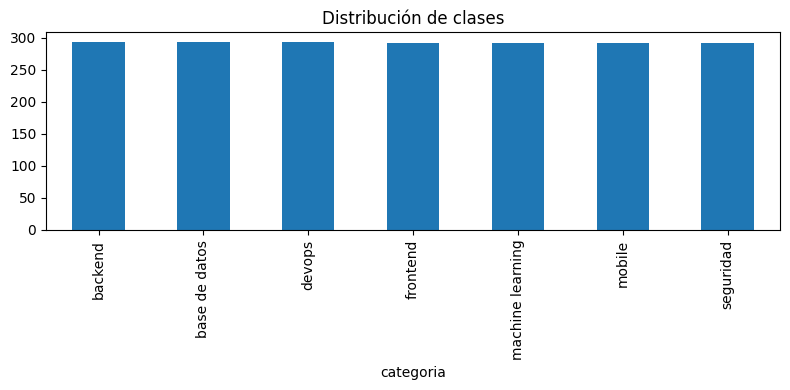

In [ ]:
eda(dataset)

##Preprocesamiento y limpieza del dataset

In [ ]:

# -----------------------------------------------------------------------
# LIMPIEZA / PREPROCESAMIENTO EN ESPAÑOL
# -----------------------------------------------------------------------

# Carga el modelo de spaCy en español (solo tokenizer + lematizador, sin NER/parser para que sea rápido)
_nlp = spacy.load("es_core_news_sm", disable=["ner", "parser"])

# Palabras propias del dominio técnico que NO deben tratarse como stopwords
EXCEPCIONES = {
    #Backend / lenguajes
    "api", "rest", "soap", "orm", "jwt", "sdk", "cli", "php", "java",
    "cplusplus", "csharp", "fsharp", "dotnet", "nodejs", "go", "rust",
    # Frontend
    "css", "html", "js", "ts", "ux", "ui", "reactjs", "vuejs", "angularjs",
    "seo",
    # Base de datos
    "sql", "nosql",
    # DevOps
    "git", "ci", "cd", "cicd", "aws", "gcp", "k8s", "ssh", "vpn", "dns",
    "ftp", "tcp", "ip", "http", "https", "json", "xml", "yaml", "npm",
    "pip", "venv", "docker",
    # Machine Learning
    "ai", "ml", "nlp", "gpu", "cpu", "ram",
    # Seguridad
    "oauth", "sso",
    # Mobile
    "ios", "apk",
}

# Términos técnicos compuestos que el regex de limpieza destruiría
# (ej. "c++" -> "c", "c#" -> "c", ".net" -> "net") si no se protegen
NORMALIZACIONES = {
    r"\bc\+\+": "cplusplus",
    r"\bc#": "csharp",
    r"\bf#": "fsharp",
    r"\.net\b": "dotnet",
    r"\bnode\.js\b": "nodejs",
    r"\bvue\.js\b": "vuejs",
    r"\breact\.js\b": "reactjs",
    r"\bangular\.js\b": "angularjs",
    r"\bci\s*/\s*cd\b": "cicd",
}

def limpiar_texto(texto: str) -> str:
    """Normaliza, quita stopwords, lematiza. Pensado para alimentar TF-IDF."""
    texto = texto.lower()

    # Protege términos compuestos ANTES de quitar símbolos como + # .
    for patron, reemplazo in NORMALIZACIONES.items():
        texto = re.sub(patron, reemplazo, texto)

    texto = re.sub(r"http\S+|www\.\S+", " ", texto)          # URLs
    texto = re.sub(r"[^\w\sáéíóúñü]", " ", texto)              # puntuación, conserva tildes/ñ
    texto = re.sub(r"\d+", " ", texto)                         # números
    texto = re.sub(r"\s+", " ", texto).strip()

    doc = _nlp(texto)
    tokens = [
        tok.lemma_ for tok in doc
        if (not tok.is_stop or tok.text in EXCEPCIONES)
        and not tok.is_punct
        and len(tok.text) > 1
    ]
    return " ".join(tokens)

def preprocesar_dataset(df: pd.DataFrame) -> pd.DataFrame:
    df["descripcion_limpia"] = df["descripcion"].apply(limpiar_texto)
    df["titulo_limpio"] = df["titulo"].apply(limpiar_texto)
    return df

In [ ]:
dataset = preprocesar_dataset(dataset)
dataset

,titulo,descripcion,tags,categoria,longitud,descripcion_limpia,titulo_limpio
0,¿Cómo servir archivos estáticos desde una apli...,Estoy desarrollando una aplicación usando Djan...,"[python, django]",backend,177,desarrollar aplicación usar django python enco...,servir archivo estático aplicación
1,No devuelve la consulta Django Postgresql al l...,apps.urls apps.views El formulario de ingresos...,[django],backend,31,apps urls apps views formulario ingreso funcio...,devolver consulta django postgresql listar
2,calcular diferencia entre fechas,Estoy tratando de calcular la diferencia entre...,"[php, date]",backend,57,tratar calcular diferencia fecha formato ejemp...,calcular diferencia fecha
3,Autocompletar input con JavaScript PHP y SQL,"[ACTUALIZADO] Bueno, logre que funcione bien, ...","[javascript, php, mysql]",backend,54,actualizado logre funcionir autocompletir inpu...,autocompletar input javascript php sql
4,"¿Cómo admitir letras, números, puntos y guione...",Necesito que en un campo de formulario sólo se...,"[php, regex]",backend,75,necesitar campo formulario poder escribir letr...,admitir letra número punto guión expresión reg...
...,...,...,...,...,...,...,...
2045,Aprendiendo Go y MariaDB: lecciones prácticas,Si estás empezando con Go y MariaDB para escri...,"[go, mariadb]",base de datos,48,estar empezar go mariadb escribir consulta pro...,aprender go mariadb lección práctico
2046,Cómo elegir las herramientas correctas en pipe...,Puse a competir Scala en un mismo problema en ...,[scala],machine learning,45,poner competir scala problema pipelín dato est...,elegir herramienta correcto pipelín dato estad...
2047,Java y MySQL cara a cara,Si tienes que elegir entre Java y MySQL para m...,"[java, mysql]",base de datos,48,tener elegir java mysql modelar consultar base...,java mysql cara cara
2048,"3 consejos si vas a usar Docker, Ruby y Python","Un consejo práctico si usas Docker, Ruby y Pyt...","[docker, ruby, python]",devops,49,consejo práctico docker ruby python pipelín in...,consejo vas docker ruby python


##Vectorización, Entrenamiento y métricas

In [ ]:
# -----------------------------------------------------------------------
# VECTORIZACIÓN
# -----------------------------------------------------------------------
from scipy.sparse import hstack

def construir_features(df, test_size=0.2, random_state=42, peso_titulo=0.5):
    X_train_df, X_test_df, y_train, y_test = train_test_split(
        df[["titulo_limpio", "descripcion_limpia"]], df["categoria"],
        test_size=test_size, random_state=random_state, stratify=df["categoria"]
    )

    vect_titulo = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), min_df=2)
    vect_texto = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)

    Xtr_titulo = vect_titulo.fit_transform(X_train_df["titulo_limpio"]) * peso_titulo
    Xtr_texto = vect_texto.fit_transform(X_train_df["descripcion_limpia"])
    X_train_tfidf = hstack([Xtr_titulo, Xtr_texto])

    Xte_titulo = vect_titulo.transform(X_test_df["titulo_limpio"]) * peso_titulo
    Xte_texto = vect_texto.transform(X_test_df["descripcion_limpia"])
    X_test_tfidf = hstack([Xte_titulo, Xte_texto])

    return vect_titulo, vect_texto, X_train_tfidf, y_train, X_test_tfidf, y_test

In [ ]:
# -----------------------------------------------------------------------
# ENTRENAMIENTO
# -----------------------------------------------------------------------

from sklearn.model_selection import GridSearchCV

def afinar_hiperparametros(X_train_tfidf, y_train):
    param_grid = {
        "C": [0.01, 0.05, 0.1, 0.3, 0.5, 1.0],
        "class_weight": ["balanced", None],
    }
    grid = GridSearchCV(
        LogisticRegression(max_iter=1000),
        param_grid, cv=5, scoring="f1_macro", n_jobs=-1
    )
    grid.fit(X_train_tfidf, y_train)

    print("Mejores parámetros:", grid.best_params_)
    print(f"Mejor F1 macro (CV): {grid.best_score_:.4f}")
    return grid.best_estimator_

In [ ]:
# -----------------------------------------------------------------------
# MÉTRICAS
# -----------------------------------------------------------------------

from sklearn.model_selection import StratifiedKFold, cross_val_score

def validacion_cruzada(df, peso_titulo: float = 2.0, k: int = 5):
    """Valida que el F1 macro sea estable y no dependa de qué filas cayeron en el split."""
    vect_titulo = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), min_df=2)
    vect_texto = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)

    X_titulo = vect_titulo.fit_transform(df["titulo_limpio"]) * peso_titulo
    X_texto = vect_texto.fit_transform(df["descripcion_limpia"])
    X_tfidf = hstack([X_titulo, X_texto])

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    modelo_cv = LogisticRegression(max_iter=1000, class_weight="balanced", C=1.0)
    scores = cross_val_score(modelo_cv, X_tfidf, df["categoria"], cv=skf, scoring="f1_macro")

    print(f"F1 macro por fold: {scores.round(4)}")
    print(f"F1 macro promedio: {scores.mean():.4f} (+/- {scores.std():.4f})")
    return scores

In [ ]:
from sklearn.metrics import f1_score, balanced_accuracy_score

def evaluar(modelo, X_test_tfidf, y_test) -> None:
    y_pred = modelo.predict(X_test_tfidf)

    print("Reporte de clasificación:\n")
    print(classification_report(y_test, y_pred))

    f1_macro = f1_score(y_test, y_pred, average="macro")
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    print(f"F1 macro (métrica principal recomendada): {f1_macro:.4f}")
    print(f"Balanced accuracy: {balanced_acc:.4f}")

    cm = confusion_matrix(y_test, y_pred, labels=modelo.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo.classes_)
    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
    plt.tight_layout()
    #plt.savefig("matriz_confusion.png")
    plt.show()
    #print("Matriz de confusión guardada en matriz_confusion.png")


In [ ]:
print("\n--- Validación cruzada (estabilidad del modelo) ---")
validacion_cruzada(dataset, peso_titulo=0.5)



--- Validación cruzada (estabilidad del modelo) ---
F1 macro por fold: [0.8885 0.8526 0.8522 0.8566 0.8737]
F1 macro promedio: 0.8647 (+/- 0.0142)


array([0.88846829, 0.85255122, 0.85219221, 0.85661663, 0.8736659 ])

Mejores parámetros: {'C': 1.0, 'class_weight': None}
Mejor F1 macro (CV): 0.8627
Reporte de clasificación:

                  precision    recall  f1-score   support

         backend       0.83      0.83      0.83        59
   base de datos       0.89      0.97      0.93        59
          devops       0.93      0.95      0.94        59
        frontend       0.86      0.95      0.90        58
machine learning       0.90      0.90      0.90        58
          mobile       0.92      0.83      0.88        59
       seguridad       0.92      0.83      0.87        58

        accuracy                           0.89       410
       macro avg       0.89      0.89      0.89       410
    weighted avg       0.89      0.89      0.89       410

F1 macro (métrica principal recomendada): 0.8921
Balanced accuracy: 0.8927


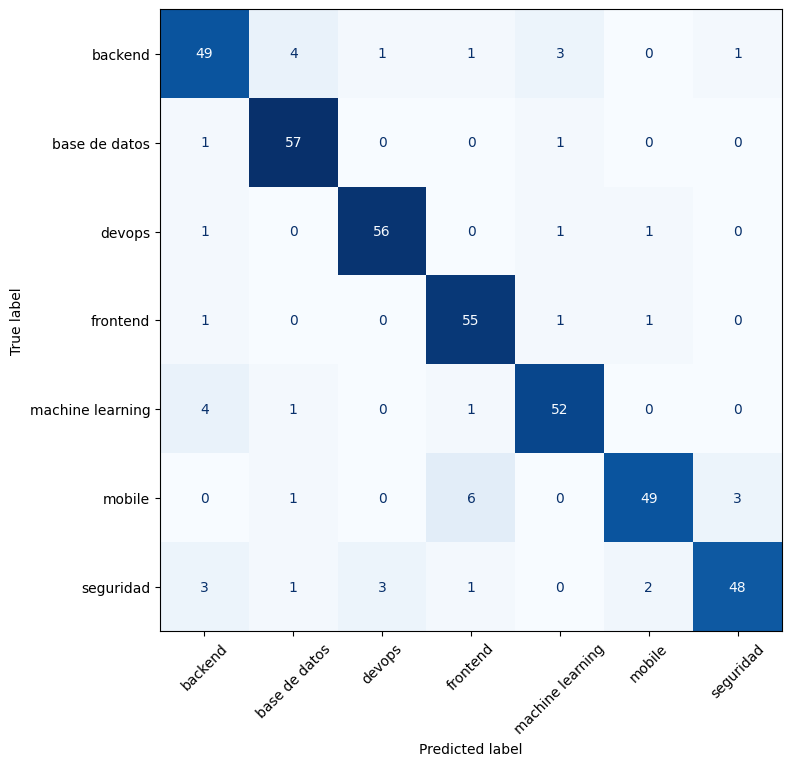

In [ ]:
vect_titulo, vect_texto, X_train_tfidf, y_train, X_test_tfidf, y_test = construir_features(dataset, peso_titulo=0.5)
modelo = afinar_hiperparametros(X_train_tfidf, y_train)

evaluar(modelo, X_test_tfidf, y_test)

In [ ]:
def diagnosticar_overfitting(modelo, X_train_tfidf, y_train, X_test_tfidf, y_test) -> None:
    score_train = modelo.score(X_train_tfidf, y_train)
    score_test = modelo.score(X_test_tfidf, y_test)
    brecha = score_train - score_test

    print(f"Accuracy train: {score_train:.4f}")
    print(f"Accuracy test:  {score_test:.4f}")
    print(f"Brecha (train - test): {brecha:.4f}")

    if brecha > 0.15:
        print("Brecha grande: posible overfitting. Considera más datos, "
              "bajar max_features, o subir la regularización (bajar C).")
    else:
        print("Brecha razonable: el modelo generaliza bien al set de test.")

In [ ]:
diagnosticar_overfitting(modelo, X_train_tfidf, y_train, X_test_tfidf, y_test)


Accuracy train: 0.9915
Accuracy test:  0.8927
Brecha (train - test): 0.0988
Brecha razonable: el modelo generaliza bien al set de test.


##Guardando modelos

In [ ]:
# -----------------------------------------------------------------------
# SERIALIZACIÓN (joblib)
# -----------------------------------------------------------------------
def guardar_modelo(modelo, vect_titulo, vect_texto,
                    ruta_modelo: str = "/content/g9-br-team-34-techmind/data-science/models/modelo_clasificador.joblib",
                    ruta_vect_titulo: str = "/content/g9-br-team-34-techmind/data-science/models/tfidf_titulo.joblib",
                    ruta_vect_texto: str = "/content/g9-br-team-34-techmind/data-science/models/tfidf_texto.joblib") -> None:
    joblib.dump(modelo, ruta_modelo)
    joblib.dump(vect_titulo, ruta_vect_titulo)
    joblib.dump(vect_texto, ruta_vect_texto)
    print(f"Modelo guardado en: {ruta_modelo}")
    print(f"Vectorizador de título guardado en: {ruta_vect_titulo}")
    print(f"Vectorizador de texto guardado en: {ruta_vect_texto}")


In [ ]:
guardar_modelo(modelo, vect_titulo, vect_texto)

Modelo guardado en: /content/g9-br-team-34-techmind/data-science/models/modelo_clasificador.joblib
Vectorizador de título guardado en: /content/g9-br-team-34-techmind/data-science/models/tfidf_titulo.joblib
Vectorizador de texto guardado en: /content/g9-br-team-34-techmind/data-science/models/tfidf_texto.joblib


##Funcion de respuesta (JSON)

In [ ]:
# -----------------------------------------------------------------------
# FUNCIÓN JSON
# -----------------------------------------------------------------------
def predecir_json_separado(titulo, texto, modelo, vect_titulo, vect_texto,
                            peso_titulo=2.0, top_n_palabras=5):
    v_titulo = vect_titulo.transform([limpiar_texto(titulo)]) * peso_titulo
    v_texto = vect_texto.transform([limpiar_texto(texto)])
    vector = hstack([v_titulo, v_texto])

    categoria = modelo.predict(vector)[0]
    probabilidad = round(float(max(modelo.predict_proba(vector)[0])), 4)

    nombres_features = list(vect_titulo.get_feature_names_out()) + list(vect_texto.get_feature_names_out())

    vector_denso = vector.toarray()[0]
    indices_top = vector_denso.argsort()[::-1][:top_n_palabras]
    palabras_clave = [nombres_features[i] for i in indices_top if vector_denso[i] > 0]

    return {
        "categoria": categoria,
        "probabilidad": probabilidad,
        "informacion_adicional": palabras_clave,
    }

##Prueba con ejemplos sinteticos

In [ ]:
ejemplos_prueba = [
    # --- Backend ---
    ("Creando una API REST con Spring Boot",
     "Aprende a construir servicios web con Java y Spring Boot, incluyendo controladores, endpoints y manejo de excepciones."),
    ("Autenticación con JWT en Node.js",
     "Implementa autenticación segura en tu backend usando tokens JWT, middleware de Express y validación de sesiones."),

    # --- Frontend ---
    ("Componentes reutilizables en React",
     "Este tutorial explica cómo crear componentes reutilizables usando props y hooks en aplicaciones React modernas."),
    ("Diseño responsivo con CSS Grid",
     "Aprende a maquetar sitios web adaptables a distintos tamaños de pantalla utilizando CSS Grid y Flexbox."),

    # --- Base de Datos ---
    ("Optimización de consultas SQL",
     "Este artículo cubre el uso de índices, joins eficientes y análisis de planes de ejecución en bases de datos relacionales."),
    ("Modelado de datos en MongoDB",
     "Explora cómo diseñar esquemas flexibles en bases de datos NoSQL usando documentos y colecciones en MongoDB."),

    # --- Mobile ---
    ("Desarrollo multiplataforma con Flutter",
     "Aprende a crear aplicaciones móviles para Android e iOS desde un solo código base usando Flutter y Dart."),
    ("Notificaciones push en Android",
     "Implementa notificaciones push utilizando Firebase Cloud Messaging en aplicaciones Android nativas."),

    # --- DevOps ---
    ("Contenedores con Docker y Docker Compose",
     "Aprende a empaquetar aplicaciones en contenedores Docker y orquestar múltiples servicios con Docker Compose."),
    ("Integración continua con GitHub Actions",
     "Configura pipelines de CI/CD automatizados para ejecutar pruebas y desplegar tu aplicación en cada commit."),

    # --- Machine Learning ---
    ("Introducción a redes neuronales con TensorFlow",
     "Este contenido explica los conceptos básicos de deep learning y cómo entrenar un modelo simple con TensorFlow."),
    ("Procesamiento de lenguaje natural en español",
     "Aprende técnicas de NLP como tokenización, lematización y vectorización TF-IDF aplicadas a textos en español."),

    # --- Seguridad ---
    ("Prevención de inyección SQL",
     "Este artículo explica cómo proteger aplicaciones web contra ataques de inyección SQL mediante consultas parametrizadas."),
    ("Autenticación de dos factores (2FA)",
     "Implementa autenticación de dos factores usando OAuth y aplicaciones autenticadoras para mejorar la seguridad de tus usuarios."),

    # --- Casos ambiguos / a propósito difíciles (mezclan categorías) ---
    ("Desplegando un modelo de Machine Learning con Docker",
     "Aprende a contenerizar un modelo entrenado en scikit-learn y exponerlo como una API REST usando FastAPI y Docker."),
    ("Seguridad en APIs REST",
     "Este contenido cubre buenas prácticas de seguridad para proteger endpoints, incluyendo autenticación JWT y validación de entradas."),
    ("Base de datos para aplicaciones móviles offline-first",
     "Explora cómo sincronizar datos locales en SQLite con una base de datos remota en aplicaciones Android sin conexión constante."),

    # --- Casos cortos / poco contexto (stress test de textos breves) ---
    ("Git para principiantes",
     "Comandos básicos de control de versiones: commit, push, pull y ramas."),
    ("¿Qué es un JOIN en SQL?",
     "Breve explicación sobre cómo combinar tablas en una base de datos relacional."),
]

print(f"Probando {len(ejemplos_prueba)} ejemplos:\n")
for titulo, texto in ejemplos_prueba:
    resultado = predecir_json_separado(titulo, texto, modelo, vect_titulo, vect_texto)
    print(f"[{titulo}]")
    print(f"  -> {resultado}\n")

Probando 19 ejemplos:

[Creando una API REST con Spring Boot]
  -> {'categoria': 'backend', 'probabilidad': 0.8729, 'informacion_adicional': ['boot', 'spring boot', 'api', 'spring', 'crear']}

[Autenticación con JWT en Node.js]
  -> {'categoria': 'backend', 'probabilidad': 0.745, 'informacion_adicional': ['nodejs', 'implemento', 'tokens', 'autenticación', 'validación']}

[Componentes reutilizables en React]
  -> {'categoria': 'mobile', 'probabilidad': 0.7727, 'informacion_adicional': ['componente', 'react', 'explicar', 'componente', 'tutorial']}

[Diseño responsivo con CSS Grid]
  -> {'categoria': 'frontend', 'probabilidad': 0.8742, 'informacion_adicional': ['grid', 'diseño', 'css', 'tamaño pantalla', 'sitio web']}

[Optimización de consultas SQL]
  -> {'categoria': 'base de datos', 'probabilidad': 0.9782, 'informacion_adicional': ['consulta sql', 'optimización', 'consulta', 'sql', 'cubrir']}

[Modelado de datos en MongoDB]
  -> {'categoria': 'base de datos', 'probabilidad': 0.9883, 'i

##Resumen de confianza y Palabras mas influyentes

In [ ]:
def resumen_confianza(ejemplos_prueba, modelo, vect_titulo, vect_texto, umbral=0.5):
    inciertos = []
    for titulo, texto in ejemplos_prueba:
        r = predecir_json_separado(titulo, texto, modelo, vect_titulo, vect_texto)
        if r["probabilidad"] < umbral:
            inciertos.append((titulo, r))

    print(f"{len(inciertos)} de {len(ejemplos_prueba)} ejemplos con probabilidad < {umbral}")
    for titulo, r in inciertos:
        print(f"  [{titulo}] -> {r}")

In [ ]:
resumen_confianza(ejemplos_prueba, modelo, vect_titulo, vect_texto)

4 de 19 ejemplos con probabilidad < 0.5
  [Procesamiento de lenguaje natural en español] -> {'categoria': 'machine learning', 'probabilidad': 0.2573, 'informacion_adicional': ['lenguaje', 'procesamiento', 'español', 'técnica', 'aplicado']}
  [Prevención de inyección SQL] -> {'categoria': 'base de datos', 'probabilidad': 0.4219, 'informacion_adicional': ['inyección sql', 'inyección', 'sql', 'inyección sql', 'inyección']}
  [Autenticación de dos factores (2FA)] -> {'categoria': 'seguridad', 'probabilidad': 0.4441, 'informacion_adicional': ['implemento', 'oauth', 'autenticación', 'mejorar', 'usuario']}
  [Base de datos para aplicaciones móviles offline-first] -> {'categoria': 'base de datos', 'probabilidad': 0.3053, 'informacion_adicional': ['móvil', 'base dato', 'base', 'aplicación', 'dato']}


In [ ]:
def palabras_mas_influyentes_por_categoria(modelo, vect_titulo, vect_texto, top_n=10):
    """
    Para cada categoría, muestra las palabras que más 'empujan' al modelo
    hacia esa clase, según el coeficiente de la Regresión Logística.
    Distingue si la palabra viene del título o del cuerpo del texto.
    """
    nombres_titulo = list(vect_titulo.get_feature_names_out())
    nombres_texto = list(vect_texto.get_feature_names_out())
    nombres = nombres_titulo + nombres_texto
    n_titulo = len(nombres_titulo)

    resultados = {}
    for i, categoria in enumerate(modelo.classes_):
        coeficientes = modelo.coef_[i]
        top_indices = coeficientes.argsort()[::-1][:top_n]

        palabras_info = []
        for idx in top_indices:
            origen = "titulo" if idx < n_titulo else "texto"
            palabras_info.append({
                "palabra": nombres[idx],
                "peso": round(float(coeficientes[idx]), 4),
                "origen": origen,
            })

        resultados[categoria] = palabras_info
        print(f"\n{categoria}:")
        for p in palabras_info:
            print(f"  {p['palabra']:20s} peso={p['peso']:+.4f}  ({p['origen']})")

    return resultados

In [ ]:
print("\n--- Explicabilidad: palabras más influyentes por categoría ---")
palabras_mas_influyentes_por_categoria(modelo, vect_titulo, vect_texto)


--- Explicabilidad: palabras más influyentes por categoría ---

backend:
  arquitectura         peso=+1.9832  (texto)
  arquitectura microservicio peso=+1.9109  (texto)
  microservicio        peso=+1.8873  (texto)
  backend aplicación   peso=+1.8384  (texto)
  java                 peso=+1.7194  (titulo)
  spring               peso=+1.6930  (texto)
  aplicación web       peso=+1.6619  (texto)
  backend              peso=+1.6192  (texto)
  django               peso=+1.5969  (titulo)
  php                  peso=+1.5270  (texto)

base de datos:
  consulta             peso=+2.8934  (texto)
  tabla                peso=+2.6954  (texto)
  sql                  peso=+1.9797  (titulo)
  esquema orms         peso=+1.9785  (texto)
  diseño esquema       peso=+1.9785  (texto)
  orms                 peso=+1.9785  (texto)
  esquema              peso=+1.9068  (texto)
  sql                  peso=+1.8915  (texto)
  base dato            peso=+1.8418  (texto)
  base                 peso=+1.6746  (texto)



{'backend': [{'palabra': 'arquitectura', 'peso': 1.9832, 'origen': 'texto'},
  {'palabra': 'arquitectura microservicio', 'peso': 1.9109, 'origen': 'texto'},
  {'palabra': 'microservicio', 'peso': 1.8873, 'origen': 'texto'},
  {'palabra': 'backend aplicación', 'peso': 1.8384, 'origen': 'texto'},
  {'palabra': 'java', 'peso': 1.7194, 'origen': 'titulo'},
  {'palabra': 'spring', 'peso': 1.693, 'origen': 'texto'},
  {'palabra': 'aplicación web', 'peso': 1.6619, 'origen': 'texto'},
  {'palabra': 'backend', 'peso': 1.6192, 'origen': 'texto'},
  {'palabra': 'django', 'peso': 1.5969, 'origen': 'titulo'},
  {'palabra': 'php', 'peso': 1.527, 'origen': 'texto'}],
 'base de datos': [{'palabra': 'consulta', 'peso': 2.8934, 'origen': 'texto'},
  {'palabra': 'tabla', 'peso': 2.6954, 'origen': 'texto'},
  {'palabra': 'sql', 'peso': 1.9797, 'origen': 'titulo'},
  {'palabra': 'esquema orms', 'peso': 1.9785, 'origen': 'texto'},
  {'palabra': 'diseño esquema', 'peso': 1.9785, 'origen': 'texto'},
  {'palab

In [ ]:
import matplotlib.pyplot as plt

def graficar_palabras_influyentes(modelo, vect_titulo, vect_texto, categoria, top_n=10):
    resultados = palabras_mas_influyentes_por_categoria(modelo, vect_titulo, vect_texto, top_n)
    datos = resultados[categoria]

    palabras = [d["palabra"] for d in datos][::-1]
    pesos = [d["peso"] for d in datos][::-1]

    plt.figure(figsize=(7, 5))
    plt.barh(palabras, pesos, color="steelblue")
    plt.title(f"Palabras más influyentes: {categoria}")
    plt.xlabel("Peso (coeficiente)")
    plt.tight_layout()
    plt.show()
    #plt.savefig(f"explicabilidad_{categoria}.png")

    #print(f"Gráfico guardado: explicabilidad_{categoria}.png")


backend:
  arquitectura         peso=+1.9832  (texto)
  arquitectura microservicio peso=+1.9109  (texto)
  microservicio        peso=+1.8873  (texto)
  backend aplicación   peso=+1.8384  (texto)
  java                 peso=+1.7194  (titulo)
  spring               peso=+1.6930  (texto)
  aplicación web       peso=+1.6619  (texto)
  backend              peso=+1.6192  (texto)
  django               peso=+1.5969  (titulo)
  php                  peso=+1.5270  (texto)

base de datos:
  consulta             peso=+2.8934  (texto)
  tabla                peso=+2.6954  (texto)
  sql                  peso=+1.9797  (titulo)
  esquema orms         peso=+1.9785  (texto)
  diseño esquema       peso=+1.9785  (texto)
  orms                 peso=+1.9785  (texto)
  esquema              peso=+1.9068  (texto)
  sql                  peso=+1.8915  (texto)
  base dato            peso=+1.8418  (texto)
  base                 peso=+1.6746  (texto)

devops:
  docker               peso=+2.7369  (texto)
  docker   

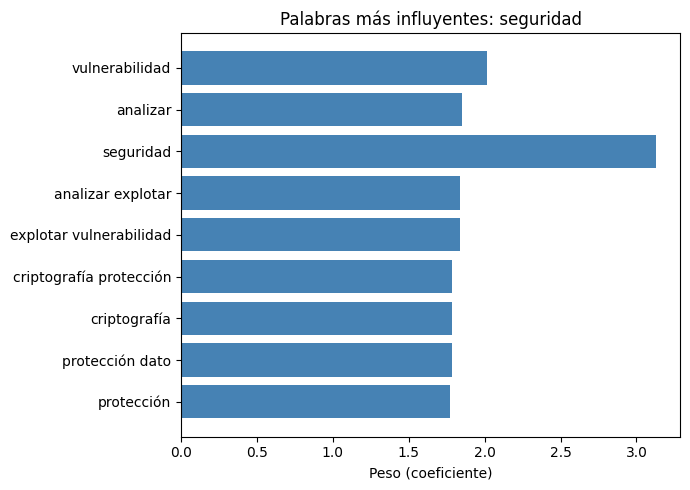

In [ ]:
graficar_palabras_influyentes(modelo, vect_titulo, vect_texto, categoria="seguridad")

## Subiendo modelos al repositorio

In [ ]:
#from google.colab import userdata
#token = userdata.get('GITHUB_TOKEN')

In [ ]:
#%cd g9-br-team-34-techmind/

/content/g9-br-team-34-techmind


In [ ]:
#!git add data-science/
#!git commit -m "model update"
#!git push https://{token}@github.com/No-Country-simulation/g9-br-team-34-techmind.git Luigui_branch

[Luigui_branch 59f30a1] model update
 3 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 data-science/models/modelo_clasificador.joblib
 create mode 100644 data-science/models/tfidf_texto.joblib
 create mode 100644 data-science/models/tfidf_titulo.joblib
Enumerating objects: 10, done.
Counting objects: 100% (10/10), done.
Delta compression using up to 2 threads
Compressing objects: 100% (7/7), done.
Writing objects: 100% (7/7), 353.05 KiB | 8.83 MiB/s, done.
Total 7 (delta 0), reused 0 (delta 0), pack-reused 0
To https://github.com/No-Country-simulation/g9-br-team-34-techmind.git
   f850771..59f30a1  Luigui_branch -> Luigui_branch
